In [1]:
import warnings
warnings.filterwarnings("ignore")

In [1]:
import numpy as np
from pcgym import make_env

# =====================================================================
# UPDATED TIMELINE PARAMETERS
# =====================================================================
T = 30.0       # Total time horizon = 30 min
nsteps = 30    # N = 30 discrete time steps (resulting in dt = 1.0 min)

# =====================================================================
# TARGET SETPOINTS (SP) FROM TABLE 2
# =====================================================================
SP = {
    'CV': [1.00 for _ in range(nsteps)],
    'Ln': [15.00 for _ in range(nsteps)]
}

# =====================================================================
# UPDATED ACTION SPACE (Incremental control bounds)
# =====================================================================
action_space = {
    'low': np.array([-1.0]),   # Minimum delta T step allowed per minute
    'high': np.array([1.0])    # Maximum delta T step allowed per minute
}

# =====================================================================
# OBSERVATION SPACE (State Bounds from Table 2 + Setpoints)
# =====================================================================
# Order: [mu0, mu1, mu2, mu3, C, CV, Ln, CV_SP, Ln_SP]
observation_space = {
    'low' : np.array([0.0, 0.0, 0.0, 0.0, 0.00, 0.00, 0.00, 0.00, 0.00]),
    'high' : np.array([1.0e20, 1.0e20, 1.0e20, 1.0e20, 0.50, 2.00, 20.00, 2.00, 20.00])
}

# =====================================================================
# ENVIRONMENT PARAMETERS SETUP
# =====================================================================
env_params = {
    'N': nsteps,
    'tsim': T,
    'SP': SP,
    'o_space': observation_space,
    'a_space': action_space,

    # Initial conditions (x0) including the initial setpoints
    'x0': np.array([1.50e3, 2.30e4, 1.80e6, 2.50e8, 0.16, 1.00, 15.00, 1.00, 15.00]),

    'r_scale': {
        'CV': 1e1,
        'Ln': 1e0
    },

    'model': 'crystallization',
    'normalise_a': True,
    'normalise_o': True,
    'noise': True,
    'integration_method': 'jax',
    'noise_percentage': 0.01,
}
# env_params['custom_reward'] = oracle_reward
# Initialize Environment
env = make_env(env_params)
obs, info = env.reset()

print("Environment successfully setted!")

Environment successfully setted!


/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/phattharapongduangkham/Documents/crystallization-partial-drl-ml/.venv/lib/python3.12/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [2]:
###
import gymnasium as gym
import joblib
import numpy as np
import xgboost as xgb
import pandas as pd
import warnings

class CrystalObservationWrapper(gym.Wrapper):

    def __init__(self, env, x_scaler_path, mu3_scaler_path, xgb_model_path):
        super().__init__(env)

        warnings.filterwarnings(
            "ignore",
            message="X does not have valid feature names, but MinMaxScaler was fitted with feature names"
        )
        self.mu3_index = 3
        # 1. Load your separate SL scalers and XGBoost model
        self.X_scaler = joblib.load(x_scaler_path)
        self.mu3_scaler = joblib.load(mu3_scaler_path)

        self.xgb_model = xgb.Booster()
        self.xgb_model.load_model(xgb_model_path)

    # def __getattr__(self, name):
    #     """
    #     If a method or attribute (like plot_rollout) is called on this wrapper
    #     but isn't explicitly defined here, intercept it and find it inside the
    #     inner pc-gym environment instead.
    #     """
    #     return getattr(self.env, name)

    def step(self, action):
        # 2. Step the actual environment using the agent's action
        obs, reward, terminated, truncated, info = self.env.step(action)

        # 3. Apply prediction logic to fix the observation
        modified_obs = self._predict_and_inject_mu3(obs)

        return modified_obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        # Modify the initial observation when resetting the environment
        obs, info = self.env.reset(**kwargs)
        modified_obs = self._predict_and_inject_mu3(obs)
        return modified_obs, info

    def _predict_and_inject_mu3(self, partial_obs):

        # print("XGBoost prediction called")

        # FIX 1: Extract features (drops the last element/mu3)
        raw_features = self._extract_features_from_obs(partial_obs)

        # Reshape to 2D array for sklearn (1 row, 8 columns)
        raw_features_2d = np.array(raw_features).reshape(1, -1)

        # 3. Define the exact feature names your training data used
        feature_names = ['mu0', 'mu1', 'mu2', 'C', 'CV', 'Ln', 'CV_SP', 'Ln_SP']

        # 4. FIX: Wrap the numpy array into a DataFrame so MinMaxScaler sees valid feature names
        raw_features_df = pd.DataFrame(raw_features_2d, columns=feature_names)

        # Scale features using the input-specific scaler
        X_scaled = self.X_scaler.transform(raw_features_df)

        # FIX 2: Since using xgb.Booster(), convert numpy array to DMatrix
        dmatrix_inputs = xgb.DMatrix(X_scaled)

        # FIX: Explicitly inject the exact feature names your model is looking for!
        dmatrix_inputs.feature_names = [
            'mu0', 'mu1', 'mu2', 'C', 'CV', 'Ln', 'CV_SP', 'Ln_SP'
        ]

        # Predict the normalized mu3
        pred_normalized_mu3 = self.xgb_model.predict(dmatrix_inputs).reshape(-1, 1)

        # Inverse-transform ONLY mu3 back to its real physical value
        actual_mu3_value = self.mu3_scaler.inverse_transform(pred_normalized_mu3)[0][0]

        # Inject the real-world mu3 into the environment's observation slot
        full_obs = self._inject_into_obs_array(partial_obs, actual_mu3_value)

        return full_obs

    def _extract_features_from_obs(self, obs):
        return np.delete(obs, self.mu3_index)

    def _inject_into_obs_array(self, obs, mu3_val):
        # Create a true writable copy of the observation array to prevent mutation warnings
        modified_obs = np.array(obs, dtype=np.float32)

        # Overwrite the last index with your newly estimated mu3 value
        modified_obs[self.mu3_index] = mu3_val
        return modified_obs

In [3]:
from stable_baselines3 import PPO

# Wrap it with your SL adaptation layer
env = CrystalObservationWrapper(
    env=env,
    x_scaler_path="../ml-training/X_scaler.pkl",
    mu3_scaler_path="../ml-training/y_scaler.pkl",
    xgb_model_path="../ml-training/xgb_model.ubj",
)

# Train PPO normally.
model = PPO("MlpPolicy", env)
model.learn(total_timesteps=30000, progress_bar=True)

: 

In [12]:
import numpy as np
import matplotlib.pyplot as plt


class CustomPolicyEvaluator:
    """
    Custom rollout evaluator for Stable-Baselines3 policies.

    Compatible with wrapped Gym environments (e.g., XGBoost observation wrapper).

    Returned data format matches pc-gym:

    data = {
        "Policy Name": {
            "x": states,
            "u": actions,
            "r": rewards
        }
    }
    """

    def __init__(self, env):
        self.env = env

    def rollout(self, policy):
        """
        Perform one rollout.

        Returns
        -------
        rewards : ndarray (N,)
        states  : ndarray (Nx, N)
        actions : ndarray (Nu, N)
        """

        obs, info = self.env.reset()

        N = self.env.unwrapped.N
        Nx = self.env.unwrapped.Nx
        Nu = self.env.unwrapped.env_params["a_space"]["low"].shape[0]

        states = np.zeros((Nx, N))
        actions = np.zeros((Nu, N))
        rewards = np.zeros(N)

        # ---------- Initial State ----------
        states[:, 0] = (
            (obs + 1)
            * (self.env.unwrapped.observation_space.high
               - self.env.unwrapped.observation_space.low)
            / 2
            + self.env.unwrapped.observation_space.low
        )

        rewards[0] = info.get("r_init", 0)

        # ---------- Rollout ----------
        for t in range(N - 1):

            action, _ = policy.predict(obs, deterministic=True)

            next_obs, reward, terminated, truncated, info = self.env.step(action)

            # store action (denormalize)
            actions[:, t] = (
                (action + 1)
                * (
                    self.env.unwrapped.env_params["a_space"]["high"]
                    - self.env.unwrapped.env_params["a_space"]["low"]
                )
                / 2
                + self.env.unwrapped.env_params["a_space"]["low"]
            )

            # store state (denormalize)
            states[:, t + 1] = (
                (next_obs + 1)
                * (self.env.unwrapped.observation_space.high
                   - self.env.unwrapped.observation_space.low)
                / 2
                + self.env.unwrapped.observation_space.low
            )

            rewards[t + 1] = reward

            obs = next_obs

            if terminated or truncated:
                break

        # final action
        action, _ = policy.predict(obs, deterministic=True)

        actions[:, -1] = (
            (action + 1)
            * (
                self.env.unwrapped.env_params["a_space"]["high"]
                - self.env.unwrapped.env_params["a_space"]["low"]
            )
            / 2
            + self.env.unwrapped.env_params["a_space"]["low"]
        )

        return rewards, states, actions

    def evaluate(self, policies, reps=10):
        """
        Evaluate one or more policies.

        Parameters
        ----------
        policies : dict
            {
                "PPO": model,
                "Another Policy": model2
            }

        reps : int

        Returns
        -------
        data : dict
            Same format as pc-gym
        """

        data = {}

        N = self.env.unwrapped.N
        Nx = self.env.unwrapped.Nx
        Nu = self.env.unwrapped.env_params["a_space"]["low"].shape[0]

        for policy_name, policy in policies.items():

            all_states = np.zeros((Nx, N, reps))
            all_actions = np.zeros((Nu, N, reps))
            all_rewards = np.zeros((1, N, reps))

            for r in range(reps):

                rewards, states, actions = self.rollout(policy)

                all_states[:, :, r] = states
                all_actions[:, :, r] = actions
                all_rewards[0, :, r] = rewards

            data[policy_name] = {
                "x": all_states,
                "u": all_actions,
                "r": all_rewards,
            }

        return data

    def plot_rewards(self, data):
        """
        Plot cumulative rewards of each policy.
        """

        plt.figure(figsize=(8, 5))

        for name in data.keys():

            rewards = data[name]["r"]

            returns = rewards.sum(axis=1).flatten()

            plt.hist(
                returns,
                bins=10,
                alpha=0.6,
                edgecolor="black",
                label=name,
            )

        plt.xlabel("Episode Return")
        plt.ylabel("Frequency")
        plt.title("Reward Distribution")
        plt.legend()
        plt.grid(True)

        plt.show()

In [13]:
evaluator = CustomPolicyEvaluator(env)

data = evaluator.evaluate(
    {
        "Partial PPO": model
    },
    reps=10
)

print(data["Partial PPO"]["r"].mean())

-121.6019619153182


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


🚀 Starting Rollout Evaluation using XGBoost Estimated mu3 states...


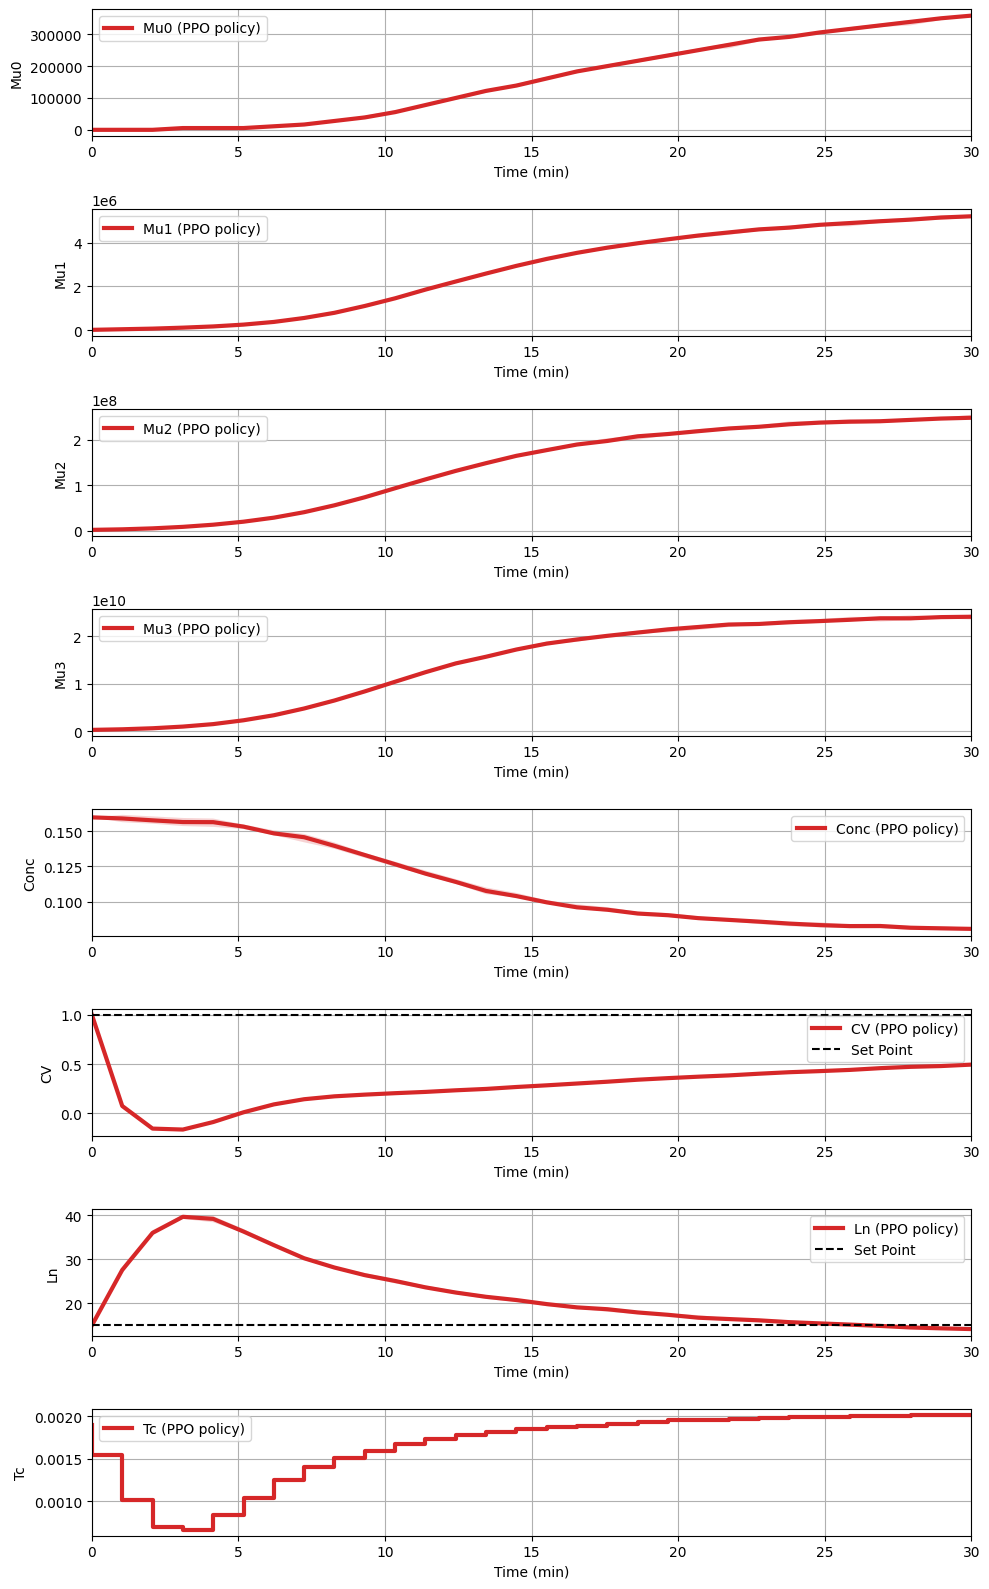

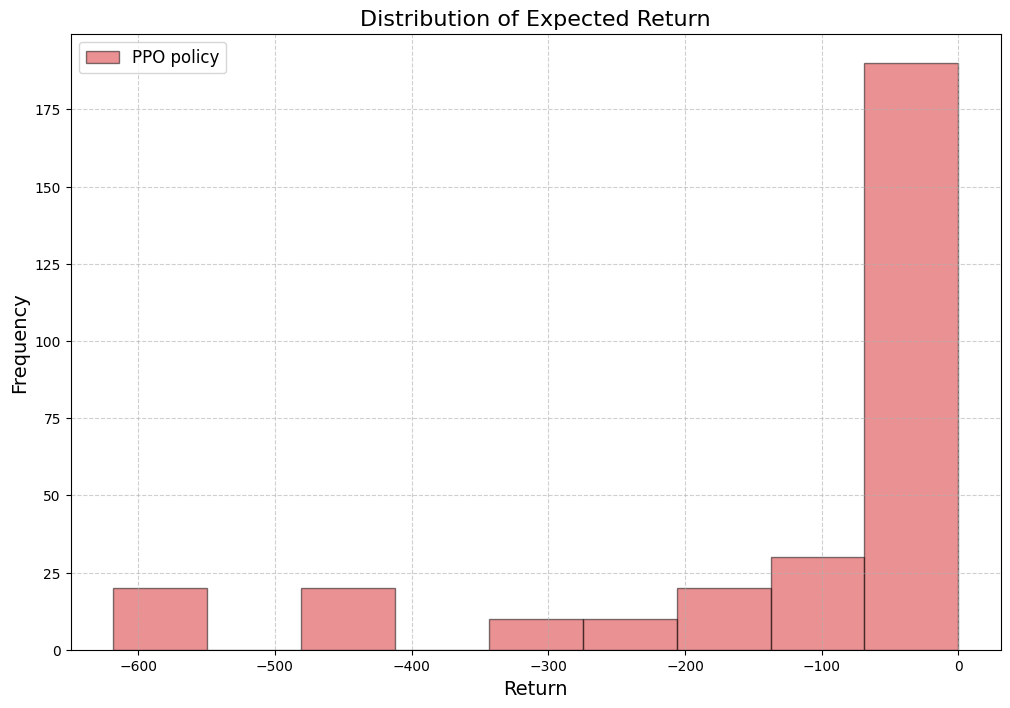

Your final score is: -121.22 (larger the better).


In [12]:
# Assuming 'env' is your wrapped environment object instance:
# env = CrystalObservationWrapper(...)

evaluator, data = env.plot_rollout(
    policies={'PPO policy': model},
    reps=10,
    oracle=False,
    dist_reward=True
)

res = data['PPO policy']['r'].mean()
print(f"Your final score is: {res:.2f} (larger the better).")

In [5]:
# import gym
import torch
import numpy as np
import os
from pcgym import make_env
# from custom_env_wrapper import CrystalObservationWrapper # Change to your actual file name

print("Initializing environment manually...")
# =====================================================================
# UPDATED TIMELINE PARAMETERS
# =====================================================================
T = 30.0       # Total time horizon = 30 min
nsteps = 30    # N = 30 discrete time steps (resulting in dt = 1.0 min)

# =====================================================================
# TARGET SETPOINTS (SP) FROM TABLE 2
# =====================================================================
SP = {
    'CV': [1.00 for _ in range(nsteps)],
    'Ln': [15.00 for _ in range(nsteps)]
}

# =====================================================================
# UPDATED ACTION SPACE (Incremental control bounds)
# =====================================================================
action_space = {
    'low': np.array([-1.0]),   # Minimum delta T step allowed per minute
    'high': np.array([1.0])    # Maximum delta T step allowed per minute
}

# =====================================================================
# OBSERVATION SPACE (State Bounds from Table 2 + Setpoints)
# =====================================================================
# Order: [mu0, mu1, mu2, mu3, C, CV, Ln, CV_SP, Ln_SP]
observation_space = {
    'low' : np.array([0.0, 0.0, 0.0, 0.0, 0.00, 0.00, 0.00, 0.00, 0.00]),
    'high' : np.array([1.0e20, 1.0e20, 1.0e20, 1.0e20, 0.50, 2.00, 20.00, 2.00, 20.00])
}

# =====================================================================
# ENVIRONMENT PARAMETERS SETUP
# =====================================================================
env_params = {
    'N': nsteps,
    'tsim': T,
    'SP': SP,
    'o_space': observation_space,
    'a_space': action_space,

    # Initial conditions (x0) including the initial setpoints
    'x0': np.array([1.50e3, 2.30e4, 1.80e6, 2.50e8, 0.16, 1.00, 15.00, 1.00, 15.00]),

    'r_scale': {
        'CV': 1e1,
        'Ln': 1e0
    },

    'model': 'crystallization',

    'normalise_a': True,
    'normalise_o': True,
    'noise': True,
    'integration_method': 'jax',
    'noise_percentage': 0.01,
}

# Initialize Environment
env = make_env(env_params)

# Establish local file paths securely
x_scaler = "/content/X_scaler.pkl"
mu3_scaler = "/content/y_scaler.pkl"
xgb_model = "/content/xgb_model.json"
print("Load scaler and Model Successfully!")
# Inject your wrapper
# Apply your wrapper adapter
env = CrystalObservationWrapper(
    env=env,
    x_scaler_path=x_scaler,
    mu3_scaler_path=mu3_scaler,
    xgb_model_path=xgb_model
)

print("Attempting manual reset...")
obs, info = env.reset()
print("Reset successful! Initial observation:", obs)

print("Attempting a single step...")
action = env.action_space.sample()
obs, reward, terminated, truncated, info = env.step(action)
print("Step successful! Next observation:", obs)

env.close()
print("All clear!")

Initializing environment manually...
Load scaler and Model Successfully!
Attempting manual reset...
Reset successful! Initial observation: [-1.0000000e+00 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00
 -3.6000001e-01  0.0000000e+00  5.0000000e-01  0.0000000e+00
  1.5452541e+10]
Attempting a single step...


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/space

Step successful! Next observation: [-1.0000000e+00 -1.0000000e+00 -1.0000000e+00 -1.0000000e+00
 -3.6668110e-01 -9.1886485e-01  1.7458869e+00  0.0000000e+00
  1.5452541e+10]
All clear!
